In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models


In [4]:
df = pd.read_csv('transcripts.csv')
df

,Comedian,Special,Transcript
0,Kate Berlant,Cinnamon in the Wind,"Whoa! Okay, yeah. Good. Okay, don’t embarrass ..."
1,Daniel Sloss,Jigsaw,“I’m just going to start up this show not with...
2,Pete Davidson,Turbo Fonzarelli,"No, it’s over, dude. It’s over. I just, uh… I ..."
3,Jerrod Carmichael,Rothaniel,"""Man… We were waiting for you. I’m happy you’r..."
4,Taylor Tomlinson,Look at You,"""Thank you! Thank you, guys, so much! Thank yo..."


In [11]:
import re
# Remove punctuation
df['Transcript'] = \
df['Transcript'].map(lambda x: re.sub('[,\.!?]', '', x))
# Convert the titles to lowercase
df['Transcript'] = \
df['Transcript'].map(lambda x: x.lower())
# Print out the first rows of papers
df['Transcript'].head()

0    whoa okay yeah good okay don’t embarrass yours...
1    “i’m just going to start up this show not with...
2    no it’s over dude it’s over i just uh… i had t...
3    "man… we were waiting for you i’m happy you’re...
4    "thank you thank you guys so much thank you i ...
Name: Transcript, dtype: object

In [12]:
# Preprocess the text
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hayleyowens/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/hayleyowens/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/hayleyowens/nltk_data...


whoa okay yeah good okay don’t embarrass yourself okay ohh the expectations crushing i would argue absolutely crushing debilitating in every way i’m gonna move this ’cause i’m so thin i’ll disappear behind it so… and then you’ll be like “is that… is that kate “or is that kate right “i don’t know who to watch is that the comedian or is that the uh the mic stand”

so… so the cameras big night for me yeah really big so there’s a camera there’s a camera huh you know they’re everywhere they can see you we can see them it’s an inherently false um moment right it’s a little bit scary they’re… they’re filming they’re not actually filming they are but it’s… is it… is the camera inherently misogynist yes right so… am i… am i… do i feel attacked yeah right it’s very… even the language you know “we’re shooting her we shot her” “we got her we have her” right it’s a… you know i feel… is it scary yeah you know… is what i do brave yeah you know… it absolutely is but i was of course forced into comedy 

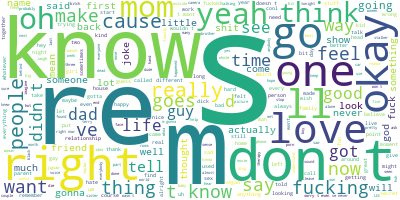

In [31]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
long_string = ','.join(list(df['Transcript'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=700, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

In [25]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['right', 'get', 'oh', 'really', 'people', 'want', 'got', 'goes', 'think', 'way', 'make', 'cause', 'use', 'one', 'say', 'yeah', 'know', 'okay', 'says', 'said', 'like', 'would', 'need', 'go'])
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
data = df.Transcript.values.tolist()
data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hayleyowens/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['whoa', 'good', 'embarrass', 'ohh', 'expectations', 'crushing', 'argue', 'absolutely', 'crushing', 'debilitating', 'every', 'gonna', 'move', 'thin', 'disappear', 'behind', 'kate', 'kate', 'watch', 'comedian', 'uh', 'mic', 'stand', 'cameras', 'big', 'night', 'big', 'camera', 'camera', 'huh']


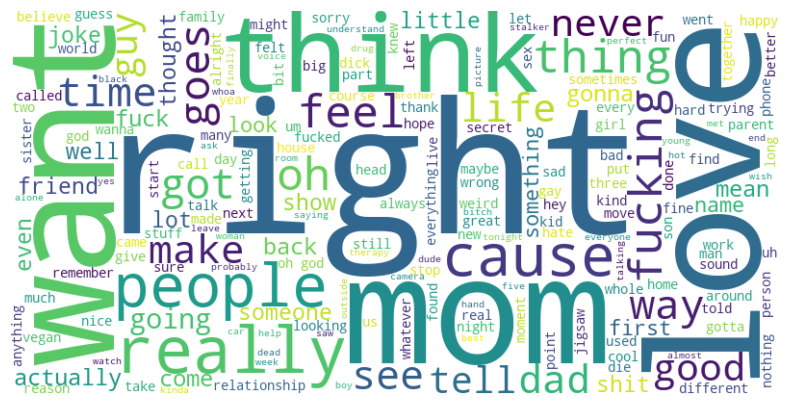

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert list of lists to a single string
long_string = ' '.join([' '.join(words) for words in data_words])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(long_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [26]:
import gensim.corpora as corpora
# Create Dictionary
id2word = corpora.Dictionary(data_words)
# Create Corpus
texts = data_words
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]
# View
print(corpus[:1][0][:30])

[(0, 1), (1, 2), (2, 7), (3, 1), (4, 2), (5, 1), (6, 1), (7, 33), (8, 3), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 2), (23, 2), (24, 1), (25, 2), (26, 8), (27, 2), (28, 3), (29, 9)]


In [27]:
from pprint import pprint
# number of topics
num_topics = 10
# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.007*"love" + 0.006*"mom" + 0.005*"good" + 0.005*"time" + 0.005*"fucking" '
  '+ 0.005*"feel" + 0.004*"never" + 0.004*"see" + 0.004*"gonna" + '
  '0.004*"life"'),
 (1,
  '0.007*"fucking" + 0.006*"love" + 0.005*"time" + 0.005*"mom" + 0.005*"good" '
  '+ 0.005*"life" + 0.005*"never" + 0.004*"feel" + 0.004*"tell" + 0.004*"see"'),
 (2,
  '0.008*"love" + 0.008*"mom" + 0.006*"feel" + 0.006*"time" + 0.005*"fucking" '
  '+ 0.005*"actually" + 0.005*"dad" + 0.004*"good" + 0.004*"see" + '
  '0.004*"lot"'),
 (3,
  '0.008*"love" + 0.006*"time" + 0.006*"mom" + 0.006*"fucking" + 0.005*"see" + '
  '0.005*"good" + 0.005*"thing" + 0.004*"never" + 0.004*"wrong" + '
  '0.004*"life"'),
 (4,
  '0.009*"love" + 0.008*"mom" + 0.007*"fucking" + 0.006*"time" + 0.005*"feel" '
  '+ 0.005*"life" + 0.004*"dad" + 0.004*"shit" + 0.004*"going" + '
  '0.004*"could"'),
 (5,
  '0.008*"mom" + 0.007*"love" + 0.005*"time" + 0.005*"dad" + 0.005*"could" + '
  '0.005*"good" + 0.005*"life" + 0.004*"fucking" + 0.004*"goi


Coherence Score: 0.2242917489069327


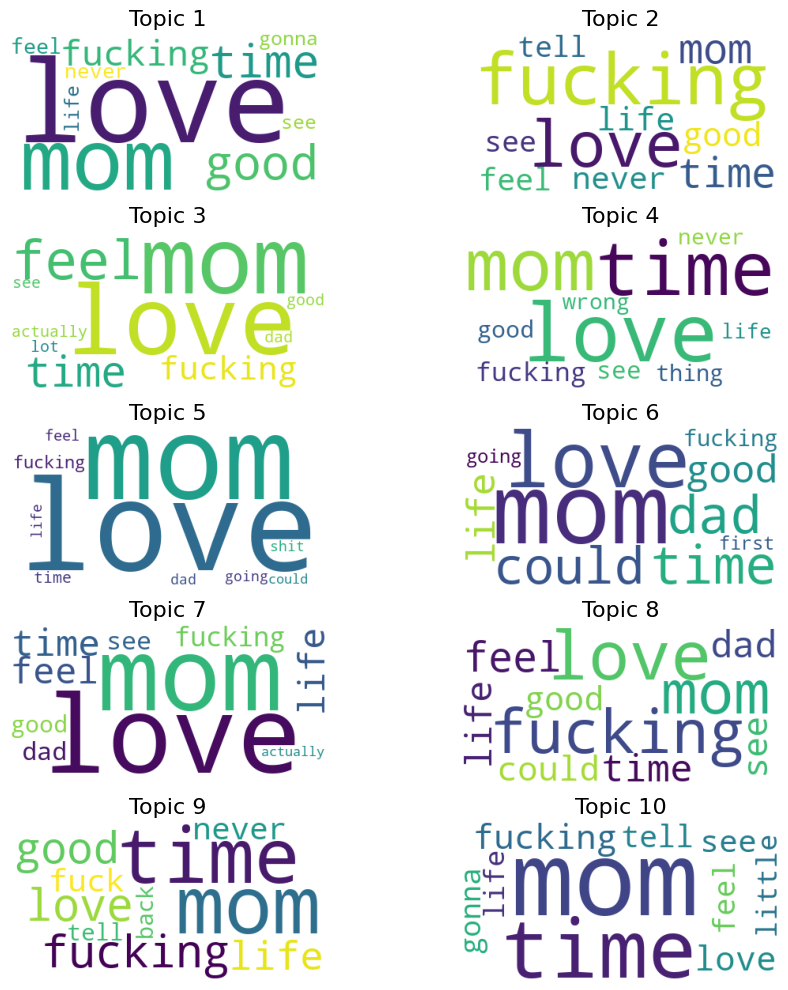

In [29]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel

# Compute coherence score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_words, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score:', coherence_lda)

# Visualize topics
topics = lda_model.show_topics(formatted=False)

# Plotting
fig, axes = plt.subplots(num_topics // 2, 2, figsize=(10,10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud = WordCloud(background_color='white').generate_from_frequencies(topic_words)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i+1), fontdict=dict(size=16))
    plt.gca().axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()